<a href="https://colab.research.google.com/github/greensky0107/self_study/blob/main/02_EDA_Pressure_MentalHealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#`Data Preprocessing`

In [44]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#### load Data

In [45]:
data = pd.read_csv('/content/sample_data/df_final.csv')

In [46]:
# 결측값 확인
data.isnull().sum()

,0
id,0
name,0
gender,0
age,0
age_group,0
city,0
profession,0
cgpa,0
degree,0
work_study_pressure,0


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51880 entries, 0 to 51879
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       51880 non-null  int64  
 1   name                     51880 non-null  object 
 2   gender                   51880 non-null  int64  
 3   age                      51880 non-null  float64
 4   age_group                51880 non-null  object 
 5   city                     51880 non-null  object 
 6   profession               51880 non-null  object 
 7   cgpa                     51880 non-null  float64
 8   degree                   51880 non-null  object 
 9   work_study_pressure      51880 non-null  float64
 10  work_study_satisfaction  51880 non-null  float64
 11  financial_stress         51880 non-null  float64
 12  sleep_duration           51880 non-null  object 
 13  dietary_habits           51880 non-null  object 
 14  work_study_hours      

In [48]:
data['gender'].value_counts()

,count
gender,
0,29425
1,22455


In [49]:
data['age_group'].value_counts()

,count
age_group,
46-55,14140
36-45,12243
26-35,9393
18-25,9082
56-65,7022


## 데이터 탐색하기

In [50]:
data.columns

Index(['id', 'name', 'gender', 'age', 'age_group', 'city', 'profession',
       'cgpa', 'degree', 'work_study_pressure', 'work_study_satisfaction',
       'financial_stress', 'sleep_duration', 'dietary_habits',
       'work_study_hours', 'family_mh_history', 'suicidal_thoughts',
       'depression', 'urban_rural'],
      dtype='object')

In [51]:
data.describe()

,id,gender,age,cgpa,work_study_pressure,work_study_satisfaction,financial_stress,work_study_hours,family_mh_history,suicidal_thoughts,depression
count,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000,51880.000000
mean,70408.881515,0.432826,40.373439,1.518318,3.048265,2.980127,3.000702,6.272899,0.499480,0.494256,0.184426
std,40628.649482,0.495472,12.438310,3.139421,1.395562,1.398014,1.415004,3.836287,0.500005,0.499972,0.387835
min,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,35221.750000,0.000000,29.000000,0.000000,2.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000
50%,70597.000000,0.000000,42.000000,0.000000,3.000000,3.000000,3.000000,6.000000,0.000000,0.000000,0.000000
75%,105737.250000,1.000000,51.000000,0.000000,4.000000,4.000000,4.000000,10.000000,1.000000,1.000000,0.000000
max,140698.000000,1.000000,60.000000,10.000000,5.000000,5.000000,5.000000,12.000000,1.000000,1.000000,1.000000


In [52]:
data.groupby('urban_rural')['city'].value_counts()

urban_rural  city     
rural        Meerut       5522
             Rajkot       5204
             Srinagar     5065
             Agra         4681
             Varanasi     4600
urban        Ahmedabad    5605
             Mumbai       4964
             Hyderabad    4491
             Bangalore    4119
             Chennai      4041
             Delhi        3588
Name: count, dtype: int64

In [53]:
data.urban_rural.value_counts()

,count
urban_rural,
urban,26808
rural,25072


In [54]:
# name, age, city 삭제 (분석과 필요 없는 칼럼)

df = data.drop(['name', 'age', 'city'], axis=1)
df.head()

,id,gender,age_group,profession,cgpa,degree,work_study_pressure,work_study_satisfaction,financial_stress,sleep_duration,dietary_habits,work_study_hours,family_mh_history,suicidal_thoughts,depression,urban_rural
0,1,0,26-35,teacher,0.0,LLB,4.0,3.0,3.0,insufficient,Unhealthy,7.0,0,1,1,rural
1,3,0,18-25,teacher,0.0,BBA,5.0,1.0,1.0,insufficient,Moderate,10.0,1,1,1,urban
2,5,1,56-65,financial analyst,0.0,MCA,2.0,5.0,5.0,insufficient,Healthy,7.0,0,0,0,urban
3,8,1,18-25,student,5.9,BSc,2.0,5.0,2.0,insufficient,Moderate,3.0,1,0,0,urban
4,10,0,46-55,software engineer,0.0,BSc,3.0,2.0,4.0,optimal,Moderate,6.0,1,0,0,rural


### 스트레스지표 비교 - urban_rural 그룹별 work_study_pressure, financial_stress
- 지역별 스트레스 특성 : 평균 및 분포 비교      
- 스트레스 검정 (동일성)

In [55]:
# 스트레스 지표는 다르게 나오는 것이 좋음
target_variables = ['work_study_pressure', 'financial_stress', 'work_study_satisfaction']

for var in target_variables:
    chi2_test(df, 'urban_rural', var)


카이제곱 통계량: 46.7992
p-value: 0.0000
'rural' 그룹과 'urban' 그룹에서 'work_study_pressure'의 분포는 다름

카이제곱 통계량: 29.0994
p-value: 0.0001
'rural' 그룹과 'urban' 그룹에서 'financial_stress'의 분포는 다름

카이제곱 통계량: 67.4551
p-value: 0.0000
'rural' 그룹과 'urban' 그룹에서 'work_study_satisfaction'의 분포는 다름


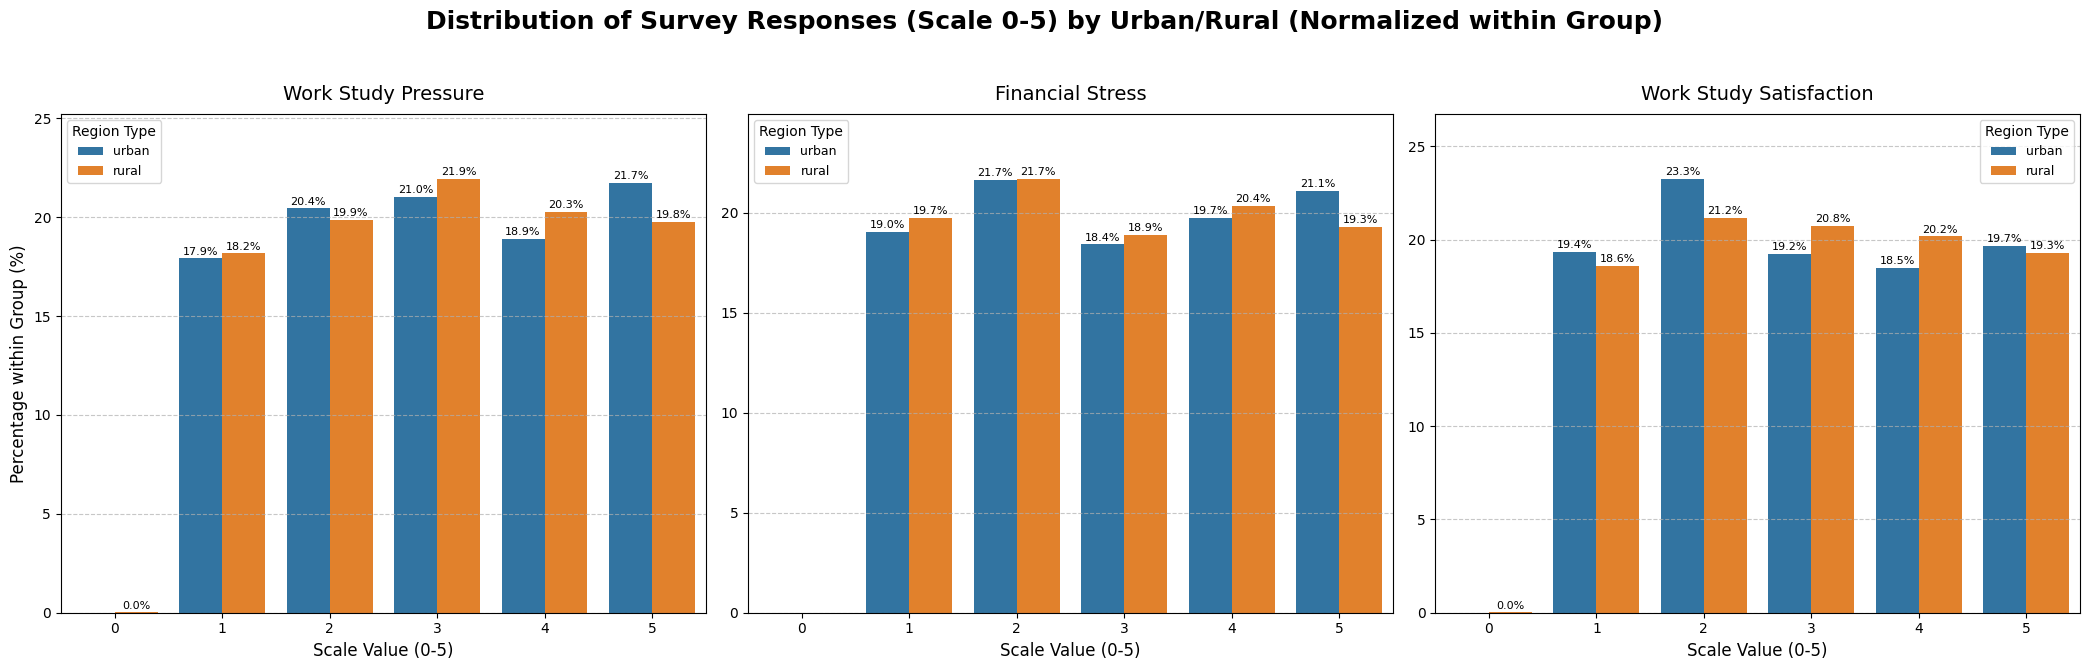

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

target_variables_numeric = ['work_study_pressure', 'financial_stress', 'work_study_satisfaction']
scale_values_to_include = [0, 1, 2, 3, 4, 5]

num_plots = len(target_variables_numeric)
fig, axes = plt.subplots(1, num_plots, figsize=(7 * num_plots, 7))
fig.suptitle('Distribution of Survey Responses (Scale 0-5) by Urban/Rural (Normalized within Group)', fontsize=18, weight='bold')

for i, var in enumerate(target_variables_numeric):
    ax = axes[i]

    df_filtered = df[df[var].isin(scale_values_to_include)].copy()
    # print(f"'{var}'에 대해 필터링된 데이터 (df_filtered) shape: {df_filtered.shape}")
    # print(df_filtered.head())

    prop_df = df_filtered.groupby('urban_rural', observed=False)[var]\
                         .value_counts(normalize=True)\
                         .mul(100)\
                         .rename('percentage')\
                         .reset_index()
    # print(f"계산된 비율 데이터 (prop_df) for '{var}':\n{prop_df}")


    # 중요: x축으로 사용될 척도 값 컬럼의 데이터 타입을 정수(int)로 변경
    if var in prop_df.columns:
        prop_df[var] = prop_df[var].astype(int)
    else:
        # prop_df 생성 로직상 이 경우는 발생하지 않아야 하지만, 방어적으로 추가
        print(f"경고: prop_df에 '{var}' 컬럼이 없습니다. prop_df:\n{prop_df.head()}")
        # 적절한 오류 처리 또는 빈 그래프 표시 로직 추가 가능
        continue

    sns.barplot(x=var, y='percentage', hue='urban_rural', data=prop_df,
                palette=['#1f77b4', '#ff7f0e'],
                order=scale_values_to_include,
                hue_order=['urban', 'rural'],
                ax=ax)

    all_percentages_zero = True
    if not prop_df.empty:
        all_percentages_zero = (prop_df['percentage'].abs() < 0.0001).all() # 매우 작은 값도 0으로 간주

    if not all_percentages_zero:
        for p in ax.patches:
            if p.get_height() > 0.01: # 0.01% 보다 큰 경우에만 주석 표시 (너무 작은 값은 제외)
                ax.annotate(f"{p.get_height():.1f}%",
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center',
                            xytext=(0, 5),
                            textcoords='offset points',
                            fontsize=8, color='black')
    elif not prop_df.empty:
         ax.text(0.5, 0.4, '모든 백분율이 0%입니다\n(또는 매우 작음).', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=9, color='grey')

    ax.set_title(f'{var.replace("_", " ").title()}', fontsize=14, pad=10, weight='medium')
    ax.set_xlabel('Scale Value (0-5)', fontsize=12)
    if i == 0: ax.set_ylabel('Percentage within Group (%)', fontsize=12)
    else: ax.set_ylabel('')

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    max_percentage_data = prop_df['percentage'].max() if not prop_df.empty else 0
    # Y축 범위를 0부터 시작하도록 하고, 최대값은 데이터에 따라 유동적으로 (최소 10%는 보이도록)
    ax.set_ylim(0, max(max_percentage_data * 1.15, 10.0))


    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles=handles, labels=labels, title='Region Type', fontsize=9, title_fontsize=10)
    elif ax.get_legend():
        ax.get_legend().remove()

    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<ipython-input-57-c352cb87f602>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=group_column, y=var, data=df, ax=ax,
<ipython-input-57-c352cb87f602>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=group_column, y=var, data=df, ax=ax,
<ipython-input-57-c352cb87f602>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=group_column, y=var, data=df, ax=ax,


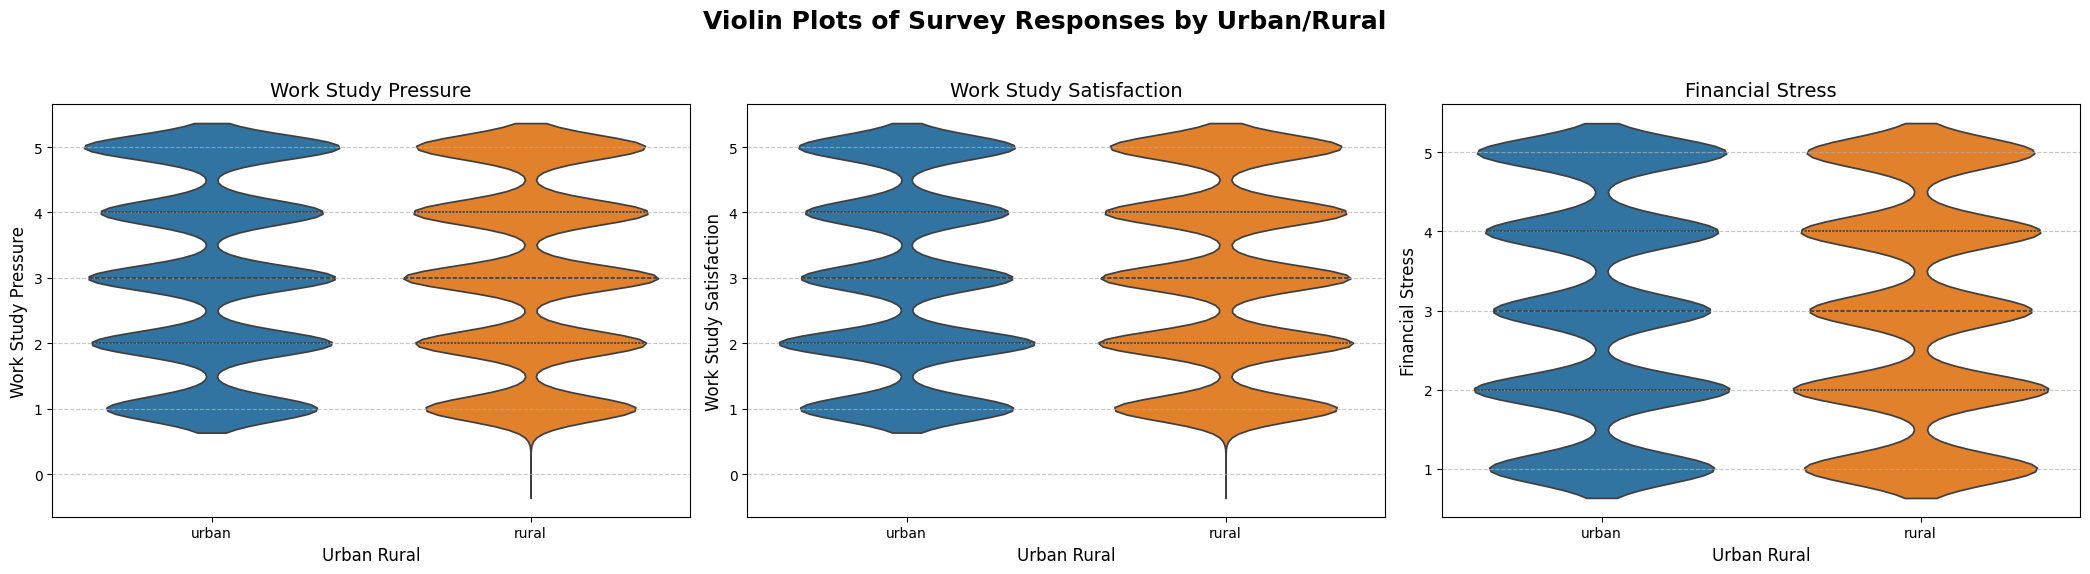

In [57]:
target_variables_violin = ['work_study_pressure', 'work_study_satisfaction', 'financial_stress']
group_column = 'urban_rural' # Column for grouping (e.g., 'urban', 'rural')

# Ensure 'urban' and 'rural' are present for consistent plotting order, if not, use existing unique values
plot_order = ['urban', 'rural']
present_groups = df[group_column].unique()
if not all(group in present_groups for group in plot_order):
    print(f"Warning: Not all specified groups ('urban', 'rural') are present in the '{group_column}' column.")
    print(f"Using existing unique groups for plotting: {list(present_groups)}")
    plot_order = list(present_groups)


# Visualization with Violin Plots
num_vars = len(target_variables_violin)
fig, axes = plt.subplots(1, num_vars, figsize=(7 * num_vars, 6), squeeze=False) # 1 row, num_vars columns

fig.suptitle('Violin Plots of Survey Responses by Urban/Rural', fontsize=18, weight='bold')

for i, var in enumerate(target_variables_violin):
    ax = axes[0, i] # Current axis

    if var not in df.columns:
        ax.text(0.5, 0.5, f"Column '{var}' not found", ha='center', va='center', fontsize=12, color='red')
        ax.set_title(f'{var.replace("_", " ").title()} (Data Missing)', fontsize=14)
        ax.axis('off') # Hide axes
        continue

    sns.violinplot(x=group_column, y=var, data=df, ax=ax,
                   palette={'urban': '#1f77b4', 'rural': '#ff7f0e'}, # Define colors for groups
                   order=plot_order, # Ensure consistent order of groups on x-axis
                   inner='quartile') # Show quartiles inside the violin: 'box', 'quartile', 'point', 'stick', None

    ax.set_title(f'{var.replace("_", " ").title()}', fontsize=14)
    ax.set_xlabel(group_column.replace("_", " ").title(), fontsize=12)
    ax.set_ylabel(var.replace("_", " ").title(), fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect for suptitle
plt.show()

--- Descriptive Statistics (Mean and Median) ---

Variable: work_study_pressure
  Overall Mean: 3.05
  Overall Median: 3.00
  Group-wise Statistics (urban_rural):
                 mean  median
urban_rural                  
rural        3.035139     3.0
urban        3.060542     3.0

Variable: work_study_satisfaction
  Overall Mean: 2.98
  Overall Median: 3.00
  Group-wise Statistics (urban_rural):
                 mean  median
urban_rural                  
rural        3.003709     3.0
urban        2.958072     3.0

Variable: financial_stress
  Overall Mean: 3.00
  Overall Median: 3.00
  Group-wise Statistics (urban_rural):
                 mean  median
urban_rural                  
rural        2.977750     3.0
urban        3.022168     3.0


<ipython-input-58-da2c8bbaa7cb>:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=group_column, y=var, ax=ax_bar,
<ipython-input-58-da2c8bbaa7cb>:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=group_column, y=var, ax=ax_bar,
<ipython-input-58-da2c8bbaa7cb>:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=group_column, y=var, ax=ax_bar,


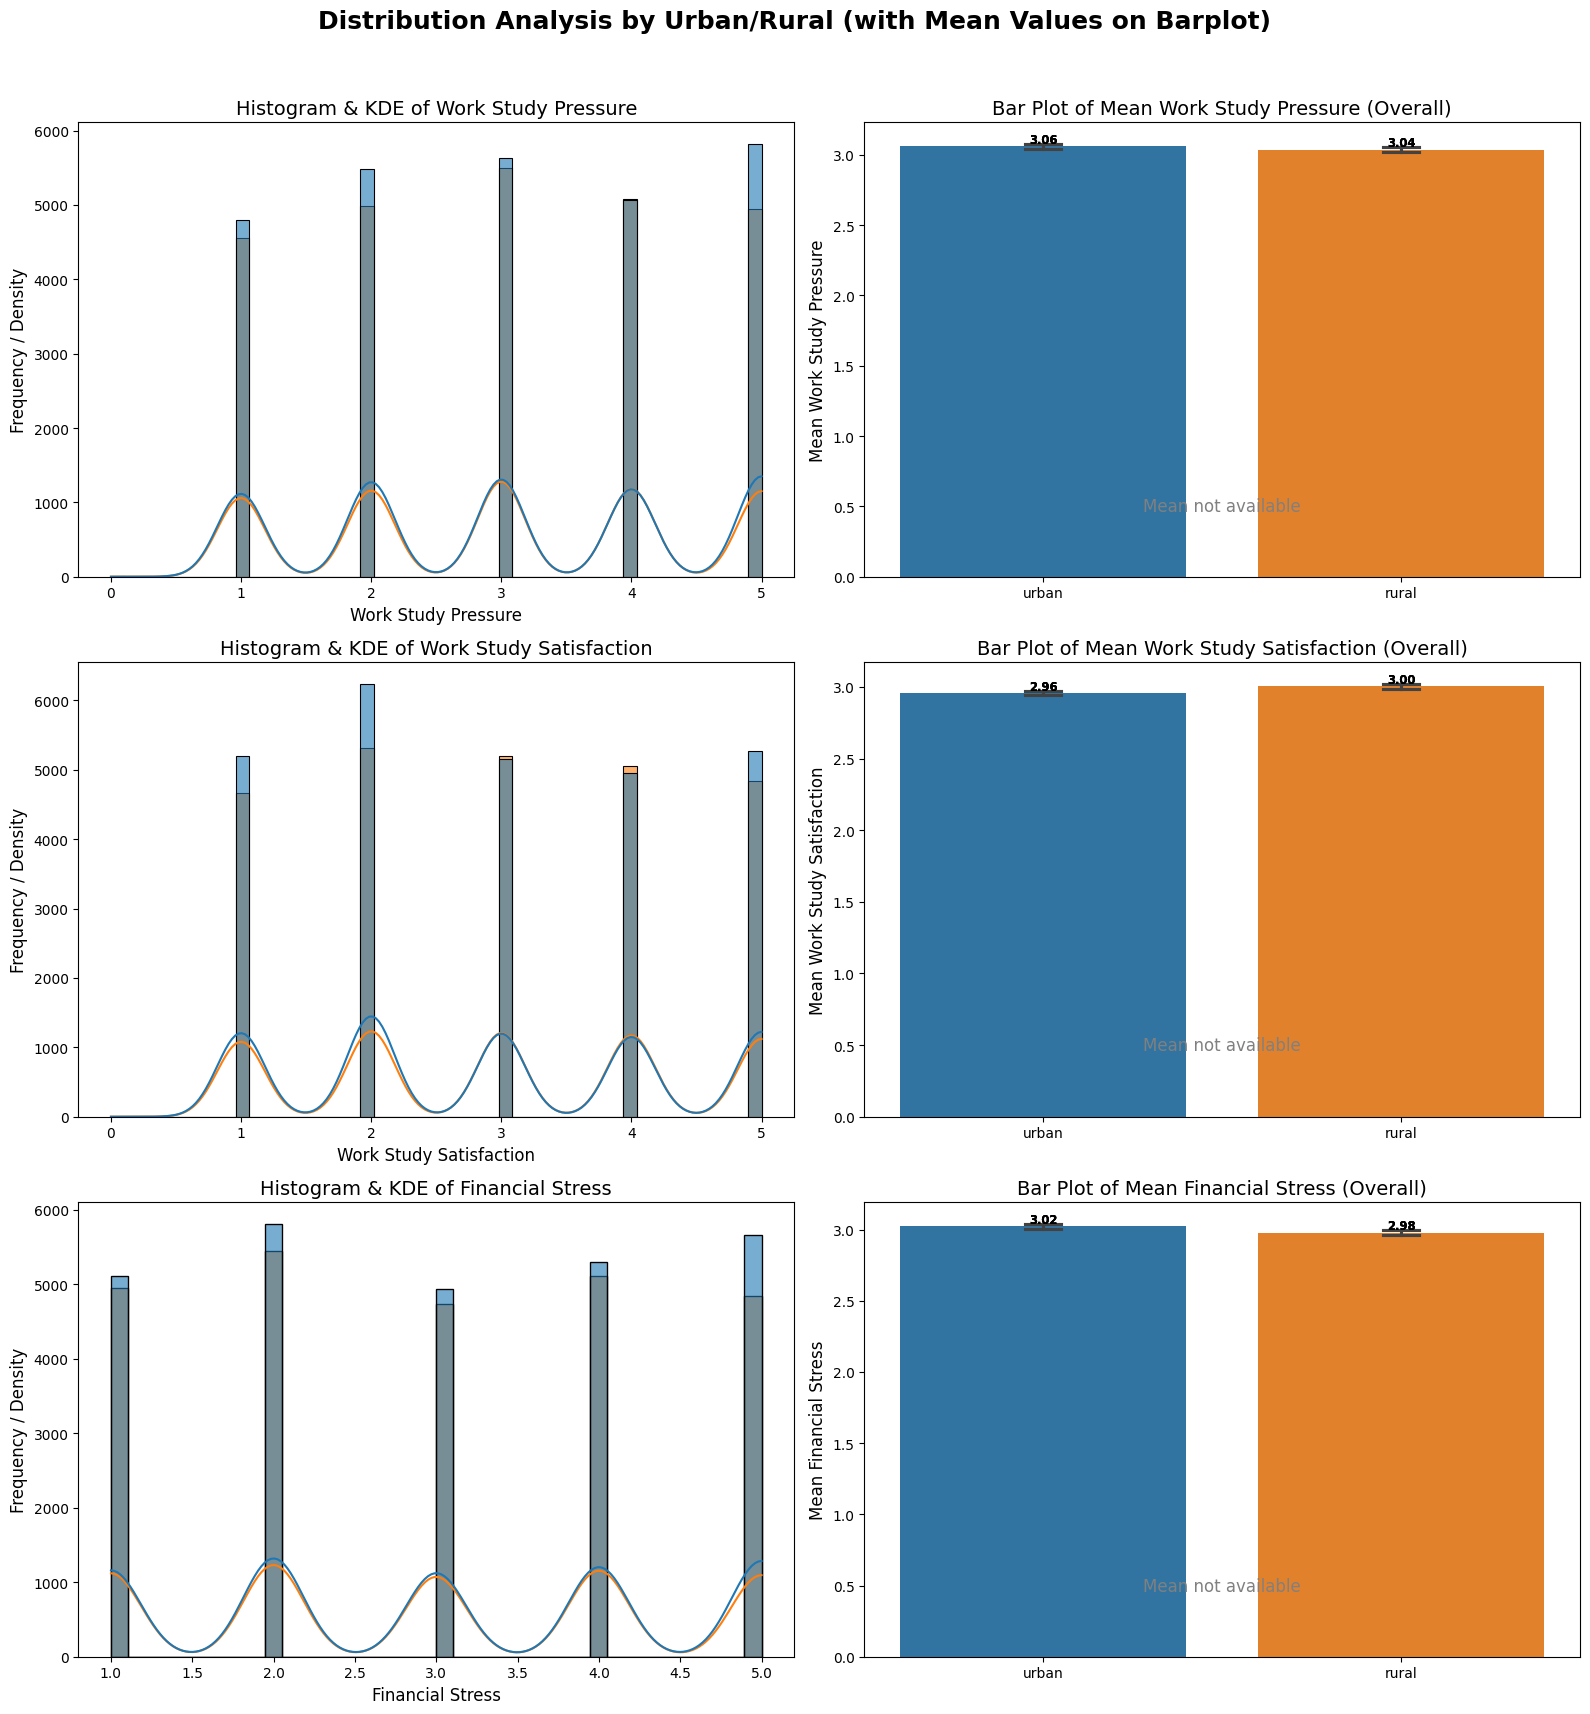

In [58]:
# Variables for analysis
target_variables = ['work_study_pressure', 'work_study_satisfaction', 'financial_stress']
group_column = 'urban_rural'

# Calculate and print descriptive statistics
print("--- Descriptive Statistics (Mean and Median) ---")
for var in target_variables:
    if var not in df.columns:
        print(f"\nWarning: Column '{var}' not found in DataFrame. Skipping statistics for this variable.")
        continue
    print(f"\nVariable: {var}")
    # Overall statistics
    overall_mean = df[var].mean()
    overall_median = df[var].median()
    print(f"  Overall Mean: {overall_mean:.2f}")
    print(f"  Overall Median: {overall_median:.2f}")

    # Group-wise statistics
    if group_column in df.columns:
        # Check if group_column has expected values 'urban' and 'rural'
        if not df[group_column].isin(['urban', 'rural']).all():
            print(f"  Warning: Column '{group_column}' contains values other than 'urban' or 'rural'. Grouped statistics might be affected.")

        grouped_stats = df.groupby(group_column)[var].agg(['mean', 'median'])
        print(f"  Group-wise Statistics ({group_column}):")
        print(grouped_stats)
    else:
        print(f"Warning: Grouping column '{group_column}' not found in DataFrame.")

# Distribution visualization
num_vars = len(target_variables)
# 2 plots per variable (histogram/KDE, barplot of means)
fig, axes = plt.subplots(num_vars, 2, figsize=(16, 6 * num_vars), squeeze=False) # Ensure axes is always 2D

fig.suptitle('Distribution Analysis by Urban/Rural (with Mean Values on Barplot)', fontsize=18, weight='bold') # Updated suptitle

for i, var in enumerate(target_variables):
    ax_hist = axes[i, 0] # Axis for histogram/KDE
    ax_bar = axes[i, 1]  # Axis for barplot (changed from ax_box)


    # 1. Histogram and KDE (group-wise)
    if group_column in df.columns and df[group_column].isin(['urban', 'rural']).any(): # Check if group_column exists and has relevant data
        sns.histplot(data=df, x=var, hue=group_column, kde=True, ax=ax_hist,
                     palette={'urban': '#1f77b4', 'rural': '#ff7f0e'},
                     alpha=0.6, hue_order=['urban', 'rural'], multiple="layer")
        ax_hist.set_title(f'Histogram & KDE of {var.replace("_", " ").title()}', fontsize=14)

    ax_hist.set_xlabel(var.replace("_", " ").title(), fontsize=12)
    ax_hist.set_ylabel('Frequency / Density', fontsize=12)
    # Ensure legend for histplot if hue was used
    if group_column in df.columns and df[group_column].isin(['urban', 'rural']).any():
        handles, labels = ax_hist.get_legend_handles_labels()
        if handles and labels:
            ax_hist.legend(title=group_column.replace("_"," ").title(), loc='upper right')
        elif ax_hist.get_legend() is not None:
            ax_hist.get_legend().remove()


    # 2. Bar Plot of Means (group-wise)
    if group_column in df.columns and df[group_column].isin(['urban', 'rural']).any():
        # Seaborn's barplot automatically calculates mean and shows confidence interval
        sns.barplot(data=df, x=group_column, y=var, ax=ax_bar,
                    palette={'urban': '#1f77b4', 'rural': '#ff7f0e'},
                    order=['urban', 'rural'], capsize=.1) # Added capsize for CI
        ax_bar.set_title(f'Bar Plot of Mean {var.replace("_", " ").title()}', fontsize=14) # Updated title
        ax_bar.set_xlabel(group_column.replace("_", " ").title(), fontsize=12)

        # Add mean annotations to the bars
        for p in ax_bar.patches:
            ax_bar.annotate(f"{p.get_height():.2f}", # Format to 2 decimal places
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 5), # Offset text slightly above the bar
                           textcoords='offset points',
                           fontsize='small', color='black', weight='semibold')


            # Add mean annotation
            for p in ax_bar.patches:
                 ax_bar.annotate(f"{p.get_height():.2f}",
                                (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='center',
                                xytext=(0, 5),
                                textcoords='offset points',
                                fontsize='small', color='black', weight='semibold')
        else:
            ax_bar.text(0.5, 0.5, "Mean not available", ha='center', va='center', fontsize=12, color='grey')
            ax_bar.set_title(f'Bar Plot of Mean {var.replace("_", " ").title()} (Overall)', fontsize=14)
            ax_bar.set_xlabel('')


    ax_bar.set_ylabel(f'Mean {var.replace("_", " ").title()}', fontsize=12) # Updated y-axis label

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # rect is for suptitle space
plt.show()


### 정신건강지표 비교 - urban_rural 그룹별 suidial_thoughts, depression
- 정신건강지표 특성 : 발생률(비율)비교, study_work_satisfaction의 평균 및 분포를 비교 (범주형 vs 범주형 : stacked bar chart)          
- 정신건강 검정(동일성)

In [59]:
# 정신건강 지표는 다르게 나오는 것이 좋음 - 가설은 도시가 더 좋을 것이다.

target_variables = ['suicidal_thoughts', 'depression']

for var in target_variables:
    chi2_test(df, 'urban_rural', var)


카이제곱 통계량: 4.3372
p-value: 0.0373
'rural' 그룹과 'urban' 그룹에서 'suicidal_thoughts'의 분포는 다름

카이제곱 통계량: 65.1902
p-value: 0.0000
'rural' 그룹과 'urban' 그룹에서 'depression'의 분포는 다름


In [60]:
# 정신건강의 가족력여부의 검정도 시행

target_variables = ['family_mh_history']

for var in target_variables:
    chi2_test(df, 'urban_rural', var)


카이제곱 통계량: 0.2160
p-value: 0.6421
rural' 그룹과 'urban' 그룹에서 'family_mh_history'의 분포는 동일


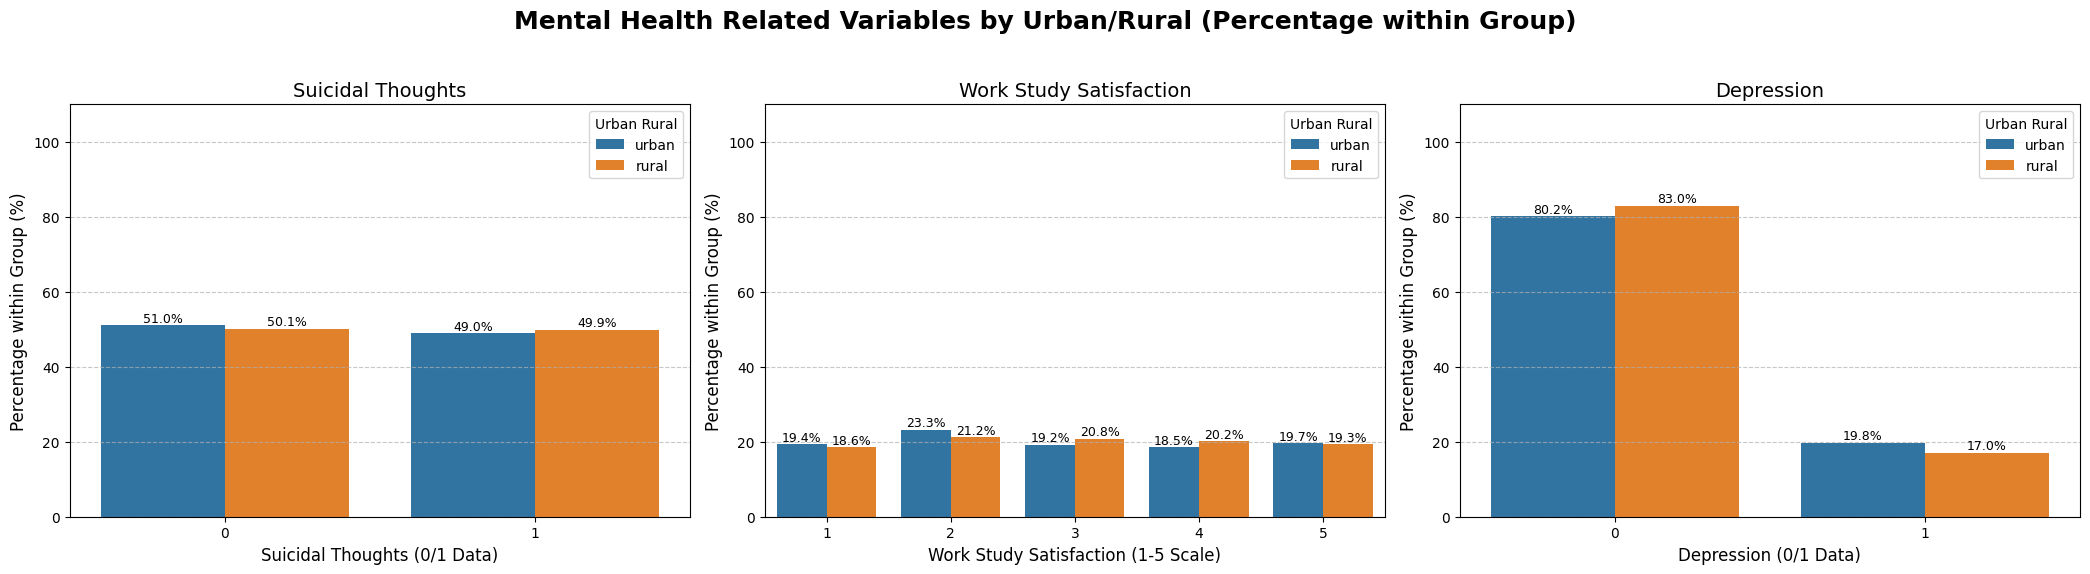

In [43]:
# Target categorical variables
# work_study_satisfaction is on a 1-5 scale, others are assumed 0/1
categorical_target_variables = ['suicidal_thoughts', 'work_study_satisfaction', 'depression']
group_column = 'urban_rural' # Grouping column

# Define plot order for 'urban_rural' for consistency
plot_order = ['urban', 'rural']
present_groups = df[group_column].unique()

# Visualization: Grouped bar graph (based on percentage within group)
num_vars = len(categorical_target_variables)
# Adjust subplot creation for the number of variables
if num_vars == 1:
    fig, ax = plt.subplots(1, 1, figsize=(8, 7)) # Single Axes object
    axes_flat = [ax] # Put it in a list to use with enumerate
else:
    fig, axes = plt.subplots(1, num_vars, figsize=(7 * num_vars, 6), squeeze=False) # 1 row, num_vars columns
    axes_flat = axes.flatten()


fig.suptitle('Mental Health Related Variables by Urban/Rural (Percentage within Group)', fontsize=18, weight='bold') # Adjusted title

for i, var in enumerate(categorical_target_variables):
    ax = axes_flat[i] # Current axis


    # Attempt to convert the target variable column to numeric, coercing errors to NaN
    df[var] = pd.to_numeric(df[var], errors='coerce')

    # Define the order for x-axis categories based on the variable
    xlabel_suffix = " (0/1 Data)" # Default for 0/1 variables
    if var == 'work_study_satisfaction':
        category_order = [1, 2, 3, 4, 5]
        xlabel_suffix = " (1-5 Scale)"
    else: # For suicidal_thoughts and depression (assumed 0/1)
        category_order = [0, 1]

    # 1. Create a working copy for this variable and drop rows where 'var' is NaN (due to coerce or originally)
    # Also drop rows where group_column is NaN if it's critical for grouping
    df_processed_var = df.dropna(subset=[var, group_column]).copy()

    # Filter for relevant categories for the current variable
    # After to_numeric, df_processed_var[var] will be float/int, so isin with numbers will work
    df_var_filtered = df_processed_var[df_processed_var[var].isin(category_order)]

    if df_var_filtered.empty:
        ax.text(0.5, 0.5, f"No data for categories {category_order}\n in variable '{var}'\nafter processing.", ha='center', va='center', fontsize=10, color='orange')
        ax.set_title(f'{var.replace("_", " ").title()} (No Data in Categories)', fontsize=14)
        ax.axis('off')
        continue

    # 2. Calculate counts for each combination of group_column and var
    counts_df = df_var_filtered.groupby([group_column, var]).size().reset_index(name='counts')

    # 3. Calculate total counts for each group_column (within the filtered categories of var)
    total_counts_group = df_var_filtered.groupby(group_column).size().reset_index(name='total_counts')


    # 4. Merge to calculate percentage
    percentage_df = pd.merge(counts_df, total_counts_group, on=group_column)
    percentage_df['percentage'] = np.where(percentage_df['total_counts'] > 0,
                                           (percentage_df['counts'] / percentage_df['total_counts']) * 100,
                                           0)


    # Ensure the x-axis variable in percentage_df is of integer type to match category_order
    if var in percentage_df.columns:
        try:
            percentage_df[var] = percentage_df[var].astype(int)
        except ValueError as e:
            print(f"Warning: Could not convert column '{var}' in percentage_df to int. Error: {e}")
            # Proceeding with original type, but plotting might be affected if types mismatch with 'order'
            pass

    # 5. Plot using sns.barplot with calculated percentages
    sns.barplot(data=percentage_df, x=var, y='percentage', hue=group_column, ax=ax,
                  palette={'urban': '#1f77b4', 'rural': '#ff7f0e'}, # Colors for groups
                  order=category_order, # Order for x-axis categories
                  hue_order=plot_order) # Order for hue groups

    ax.set_title(f'{var.replace("_", " ").title()}', fontsize=14)
    ax.set_xlabel(var.replace("_", " ").title() + xlabel_suffix, fontsize=12)
    ax.set_ylabel('Percentage within Group (%)', fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 110) # Set Y-axis from 0 to 110 to accommodate 100% and annotations

    # Add percentage annotations on top of each bar
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}%",
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='center',
                          xytext=(0, 5),
                          textcoords='offset points',
                          fontsize=9, color='black')

    # Configure legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        legend_title = group_column.replace("_"," ").title()
        ax.legend(handles=handles, labels=labels, title=legend_title, loc='upper right')
    elif ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for suptitle if it exists and is not empty
if fig._suptitle is not None and fig._suptitle.get_text() != '':
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
else:
    plt.tight_layout()

plt.show()
